In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/suicide.csv')
df

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,"63,067,077,179",2309,Silent
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z


In [ ]:
df.columns

Index(['country', 'year', 'sex', 'age', 'suicides_no', 'population',
       'suicides/100k pop', 'country-year', 'HDI for year',
       ' gdp_for_year ($) ', 'gdp_per_capita ($)', 'generation'],
      dtype='object')

In [ ]:
suicide_no_year = df.groupby('year')[['suicides_no']].sum().reset_index()

In [ ]:
suicide_no_year

,year,suicides_no
0,1985,116063
1,1986,120670
2,1987,126842
3,1988,121026
4,1989,160244
5,1990,193361
6,1991,198020
7,1992,211473
8,1993,221565
9,1994,232063


In [ ]:
sns.set_theme()

Text(0, 0.5, 'Suicides')

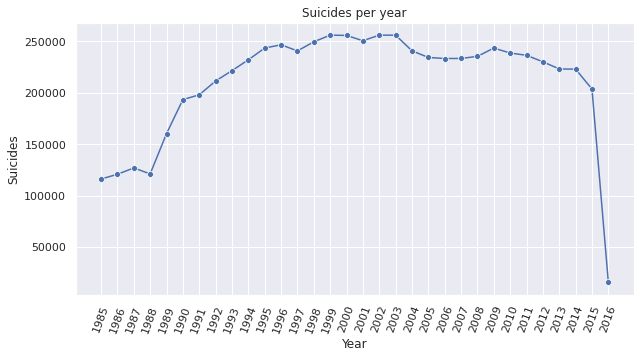

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(data=suicide_no_year, x='year', y='suicides_no', marker="o")
ax.set(xticks=suicide_no_year.year)
plt.xticks(rotation=70)

plt.title('Suicides per year')
plt.xlabel('Year')
plt.ylabel('Suicides')

In [ ]:
yearly_suicides_100k = df.groupby('year')[['suicides/100k pop']].sum().reset_index()
yearly_suicides_100k

,year,suicides/100k pop
0,1985,6811.89
1,1986,6579.84
2,1987,7545.45
3,1988,7473.13
4,1989,8036.54
5,1990,9878.75
6,1991,10321.06
7,1992,10528.88
8,1993,10790.29
9,1994,11483.79


Text(0, 0.5, 'Suicides per 100k population')

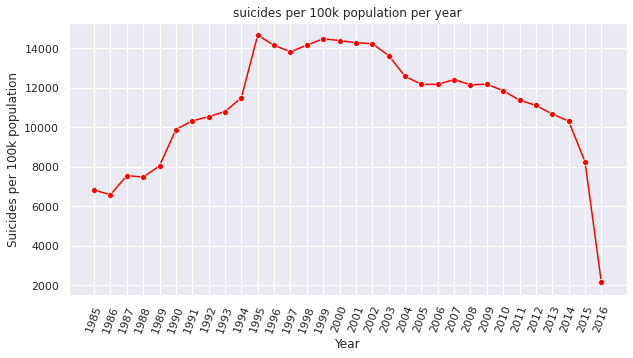

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(data=yearly_suicides_100k, x='year', y='suicides/100k pop', marker="o",color='red')
ax.set(xticks=yearly_suicides_100k.year)
plt.xticks(rotation=70)

plt.title('suicides per 100k population per year')
plt.xlabel('Year')
plt.ylabel('Suicides per 100k population')

In [ ]:
top_countries = df.groupby(['country'])['suicides_no'].sum().sort_values(ascending=False).head(10)
top_countries.index

Index(['Russian Federation', 'United States', 'Japan', 'France', 'Ukraine',
       'Germany', 'Republic of Korea', 'Brazil', 'Poland', 'United Kingdom'],
      dtype='object', name='country')

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0, 0.5, 'Country')

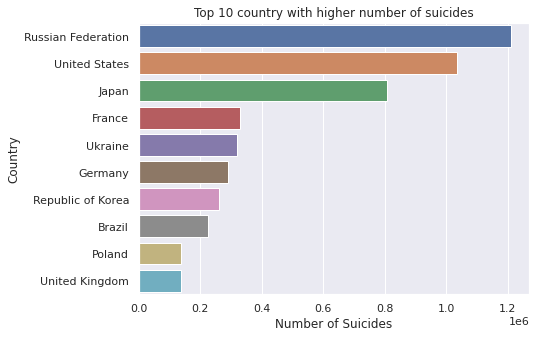

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.barplot(top_countries, top_countries.index)

plt.title('Top 10 country with higher number of suicides')
plt.xlabel('Number of Suicides')
plt.ylabel('Country')

In [ ]:
sex = df.groupby('sex')[['suicides_no']].sum().reset_index()
sex

,sex,suicides_no
0,female,1559510
1,male,5188910


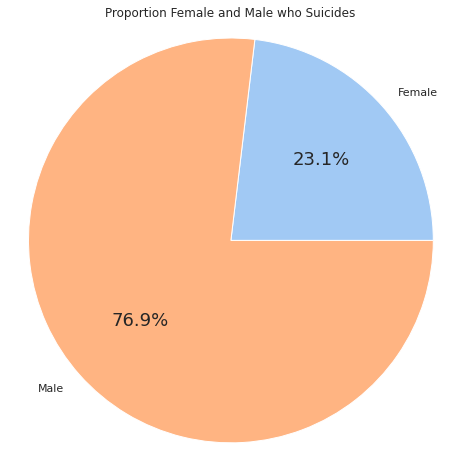

In [ ]:
plt.figure(figsize=(8,8))
plt.rcParams['font.size'] = 18

x = sex['sex']
y = list(sex['suicides_no'])

labels = ['Female', 'Male']
sizes = y

colors = sns.color_palette('pastel')

plt.pie(sizes, labels=labels, colors=colors,autopct='%1.1f%%')
plt.title('Proportion Female and Male who Suicides')
plt.axis('equal')
plt.show()

In [ ]:
suicides_no_age = []
for a in df['age'].unique():
    suicides_no_age.append(sum(df[df['age'] == a]['suicides_no']))
suicides_no_age

[808542, 2452141, 653118, 1123912, 1658443, 52264]

Text(0, 0.5, 'no. of suicides')

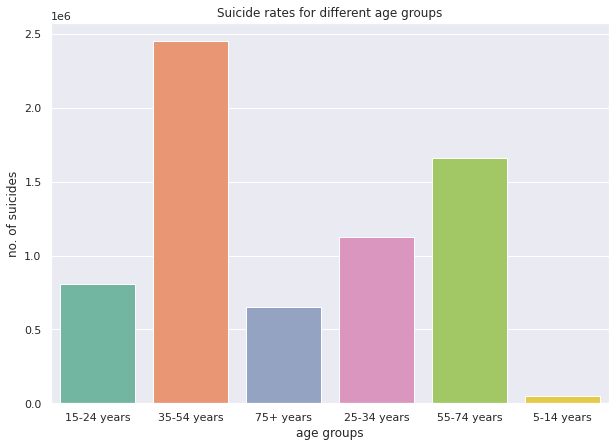

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(x = df['age'].unique(), y = suicides_no_age, palette='Set2');

plt.title('Suicide rates for different age groups')
plt.xlabel('age groups')
plt.ylabel('no. of suicides')

In [ ]:
suicides_no_age_100k = []
for a in df['age'].unique():
    suicides_no_age_100k.append(sum(df[df['age'] == a]['suicides/100k pop']))
suicides_no_age_100k

[41532.69000000003,
 69386.01999999999,
 111201.01000000008,
 56571.520000000055,
 74994.20000000007,
 2858.389999999998]

Text(0, 0.5, 'no. of suicides per 100k population')

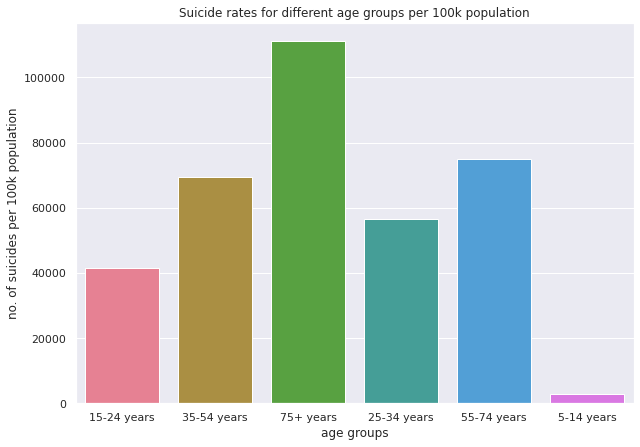

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(x = df['age'].unique(), y = suicides_no_age_100k, palette='husl');

plt.title('Suicide rates for different age groups per 100k population')
plt.xlabel('age groups')
plt.ylabel('no. of suicides per 100k population')

In [ ]:
generation_suicides = df.groupby('generation')[['suicides_no']].sum()['suicides_no']
generation_suicides

generation
Boomers            2284498
G.I. Generation     510009
Generation X       1532804
Generation Z         15906
Millenials          623459
Silent             1781744
Name: suicides_no, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0, 0.5, 'no. of suicides')

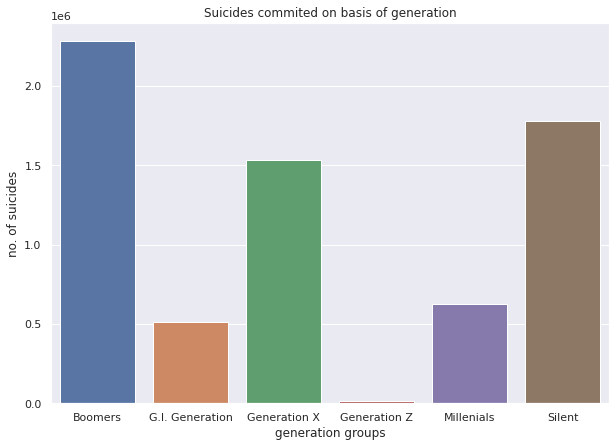

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(generation_suicides.index, generation_suicides)

plt.title('Suicides commited on basis of generation')
plt.xlabel('generation groups')
plt.ylabel('no. of suicides')

Text(0.5, 1.0, 'Population Vs No of Suicides')

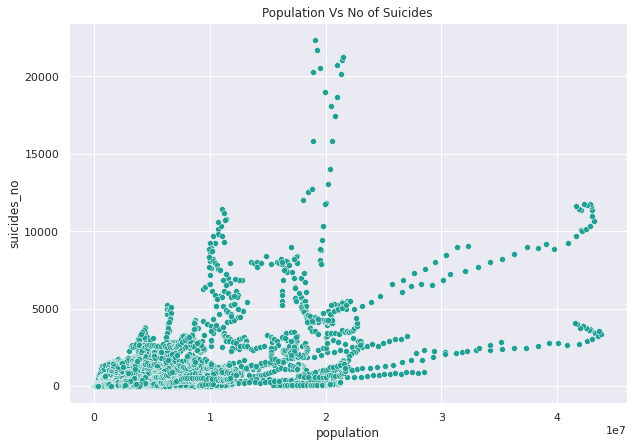

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(x='population', y='suicides_no', data=df, color='#219F94')

plt.title('Population Vs No of Suicides')

Text(0.5, 1.0, 'GDP Per Capita Vs No of Suicides')

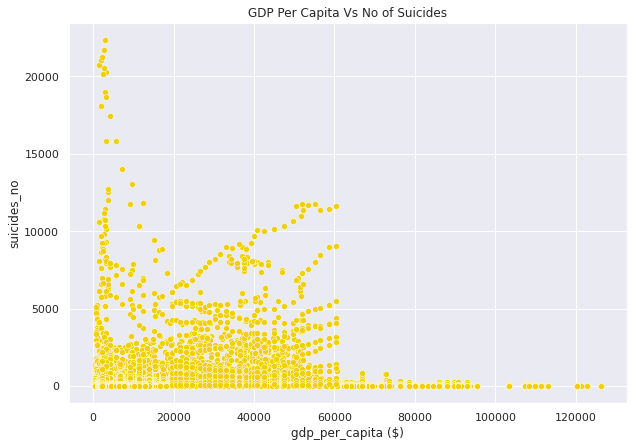

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(x='gdp_per_capita ($)', y='suicides_no', data=df, color='#F1D00A')

plt.title('GDP Per Capita Vs No of Suicides')

Text(0.5, 1.0, 'HDI Per Year Vs No of Suicides')

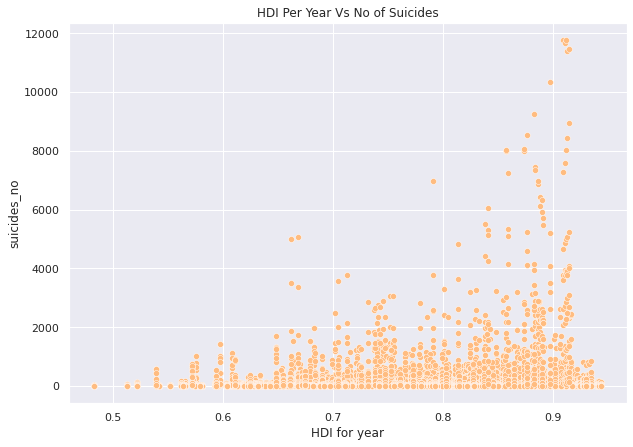

In [ ]:
plt.figure(figsize=(10,7))

sns.scatterplot(x='HDI for year', y='suicides_no', data=df, color='#FFBC80')

plt.title('HDI Per Year Vs No of Suicides')

Text(0.5, 1.0, 'Correlation Plot')

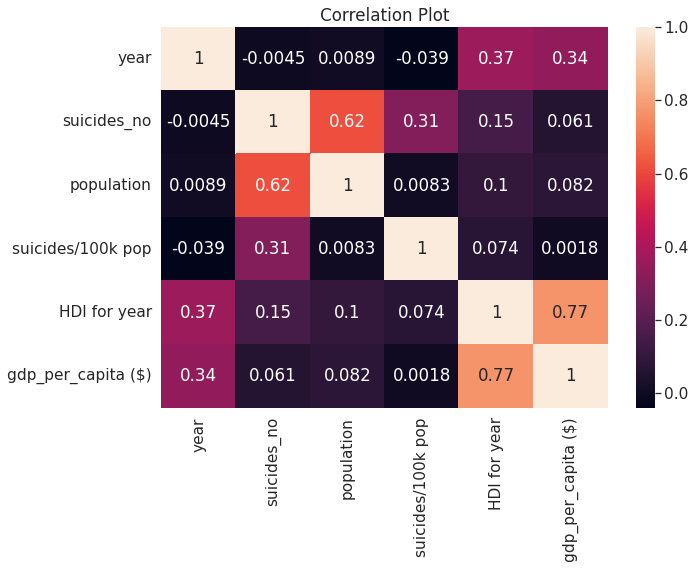

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(),annot=True)

plt.title('Correlation Plot')